# Dependency Installation and Imports

In [ ]:
!pip install opencv-python mediapipe==0.10.14 matplotlib seaborn tensorflow scikit-learn tensorflowjs

In [1]:
# %%
import cv2
import mediapipe as mp
import numpy as np
import os
from time import time

2026-03-15 14:41:05.950303: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 14:41:05.955986: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-15 14:41:05.975278: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773556866.006486   80152 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773556866.015684   80152 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773556866.038374   80152 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

# Data Collection

In [2]:
# %%
GESTURE_CLASSES = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "Unknown"]
DATA_PATH = "numbers_static_dataset"
SAMPLES_PER_GESTURE = 300
CENTER_BY_WRIST = True
FLATTEN = True
INCLUDE_HANDEDNESS = True

os.makedirs(DATA_PATH, exist_ok=True)
for g in GESTURE_CLASSES:
    os.makedirs(os.path.join(DATA_PATH,g), exist_ok=True)

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1,
                       min_detection_confidence=0.7,
                       min_tracking_confidence=0.7)

cap = cv2.VideoCapture(0)

for gesture in GESTURE_CLASSES:
    print(f"Collecting: {gesture}")
    count = 0
    while count < SAMPLES_PER_GESTURE:
        ret, frame = cap.read()
        if not ret:
            continue

        frame = cv2.flip(frame,1)
        rgb = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)

        keypoints = None
        if result.multi_hand_landmarks:
            lm = result.multi_hand_landmarks[0]
            mp_draw.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
            pts = np.array([[p.x,p.y,p.z] for p in lm.landmark])
            if CENTER_BY_WRIST:
                pts -= pts[0]
            if FLATTEN:
                pts = pts.flatten()
            if INCLUDE_HANDEDNESS and result.multi_handedness:
                handlabel = result.multi_handedness[0].classification[0].label
                pts = np.append(pts, 0 if handlabel=="Left" else 1)
            keypoints = pts

        cv2.putText(frame,f"{gesture} {count}/{SAMPLES_PER_GESTURE}",(10,30),
                    cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,255,0),2)
        cv2.imshow("Collect Gestures", frame)
        k = cv2.waitKey(1) & 0xFF

        if k==ord("c") and keypoints is not None:
            np.save(os.path.join(DATA_PATH,gesture,f"{count:03d}.npy"), keypoints)
            count +=1

        if k==ord("q"):
            break

cap.release()
cv2.destroyAllWindows()
print("Done collecting!")

I0000 00:00:1773556872.067695   80152 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1773556872.079733   81371 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (WHL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773556872.145578   81363 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773556872.238491   81359 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Collecting: 0


QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ fo

Collecting: 1
Collecting: 2
Collecting: 3
Collecting: 4
Collecting: 5
Collecting: 6
Collecting: 7
Collecting: 8
Collecting: 9
Collecting: 10
Collecting: Unknown
Done collecting!


# Data Splitting and Preprocessing

In [3]:
# %%
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

# Load
X,y = [],[]
for i,gesture in enumerate(GESTURE_CLASSES):
    folder = os.path.join(DATA_PATH,gesture)
    for f in os.listdir(folder):
        X.append(np.load(os.path.join(folder,f)))
        y.append(i)

X,y = np.array(X),np.array(y)
y = to_categorical(y,len(GESTURE_CLASSES))

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Train:",X_train.shape,"Test:",X_test.shape)

Train: (2880, 64) Test: (720, 64)


In [4]:
# %%
# Build MLP
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(GESTURE_CLASSES), activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

/home/bennybun29/Documents/jupyter_projects/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-15 14:46:02.452089: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,356 (67.80 KB)

 Trainable params: 17,356 (67.80 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [5]:
# %%
history = model.fit(X_train,y_train, validation_data=(X_test,y_test),
                    epochs=50, batch_size=16)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2965 - loss: 2.1576 - val_accuracy: 0.6111 - val_loss: 1.6023
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6260 - loss: 1.2212 - val_accuracy: 0.8514 - val_loss: 0.7669
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7889 - loss: 0.7270 - val_accuracy: 0.9264 - val_loss: 0.4303
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8726 - loss: 0.4614 - val_accuracy: 0.9833 - val_loss: 0.2347
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9365 - loss: 0.2905 - val_accuracy: 0.9861 - val_loss: 0.1297
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9611 - loss: 0.2000 - val_accuracy: 0.9889 - val_loss: 0.0812
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9691 - loss: 0.1562 - val_accuracy: 0.9931 - val_loss: 0.0565
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9816 - loss: 0.1131 - val_accuracy: 0.

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
NORMAL TEST
Accuracy: 0.9930555555555556
Recall:   0.9933527050667009
F1:       0.9932188071715977
MSE:      0.3402777777777778


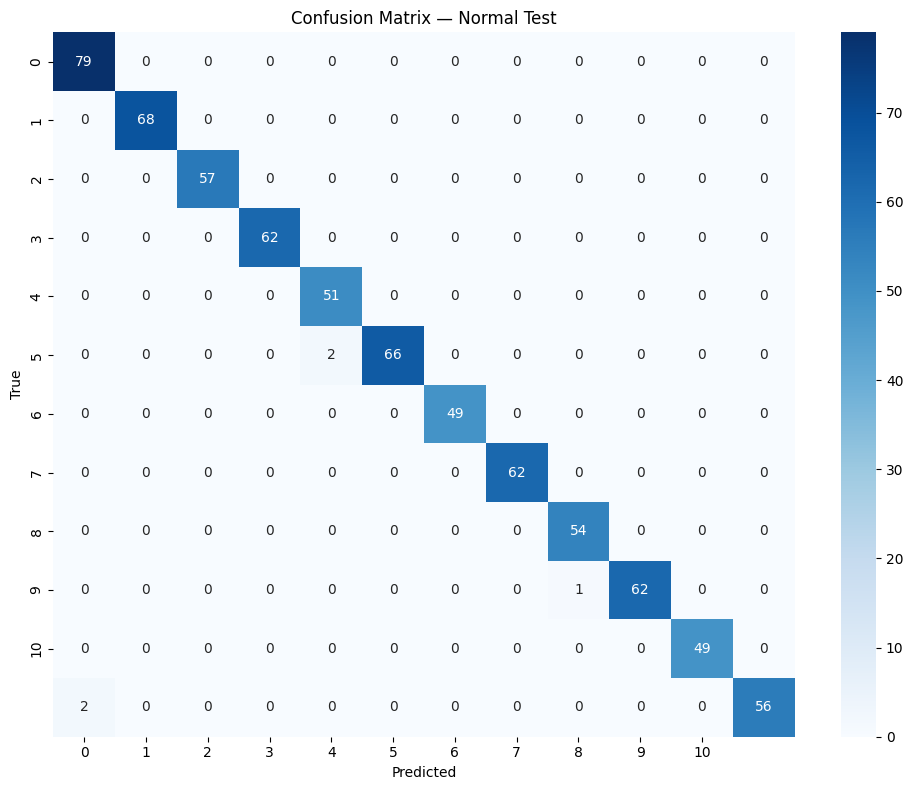

In [8]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, mean_squared_error

acc = accuracy_score(y_true, y_pred)
rec = recall_score(y_true, y_pred, average='macro')
f1  = f1_score(y_true, y_pred, average='macro')
mse = mean_squared_error(y_true, y_pred)

GESTURE_CLASSES = [str(i) for i in range(11)]  # ["0","1",...,"10"]

print("NORMAL TEST")
print("Accuracy:", acc)
print("Recall:  ", rec)
print("F1:      ", f1)
print("MSE:     ", mse)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURE_CLASSES,
            yticklabels=GESTURE_CLASSES)
plt.title("Confusion Matrix — Normal Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# Model Export and TFJS / TFLite conversion

In [9]:
model.export("numbers_model")
print("SavedModel export complete!")

INFO:tensorflow:Assets written to: numbers_model/assets


INFO:tensorflow:Assets written to: numbers_model/assets


Saved artifact at 'numbers_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  137605249874640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137605249875408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137605249874064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604984030224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137605249874448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604984030032: TensorSpec(shape=(), dtype=tf.resource, name=None)
SavedModel export complete!


In [ ]:
# Go to google colab to convert to tfjs_model
# !pip install tensorflowjs
# !tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model numbers_model tfjs_numbers_model

In [12]:
# %%
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("saved_model_new")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("numbers_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")

TFLite model saved!


W0000 00:00:1772105954.186678    7541 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772105954.186764    7541 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-02-26 19:39:14.187979: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: saved_model_new
2026-02-26 19:39:14.191110: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-26 19:39:14.191242: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: saved_model_new
I0000 00:00:1772105954.212301    7541 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-02-26 19:39:14.216087: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-26 19:39:14.302791: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: saved_model_new
2026-02-26 19:39:14.317670: I tensorflow/cc/saved_model/loader.cc:471] SavedModel loa

# Edge Case Testing for Platform Technologies

In [12]:
# EDGE CASE 1 — Incomplete Landmark Input Robustness Test - Simulates hand partially outside frame, detection failure, cropped hand

import numpy as np

def occlude_features(X, percent=0.2):
    X_mod = X.copy()
    n_feat = X.shape[1]
    n_remove = int(n_feat*percent)

    for i in range(len(X_mod)):
        idx = np.random.choice(n_feat,n_remove,replace=False)
        X_mod[i,idx] = 0
    return X_mod

X_test_occ = occlude_features(X_test,0.2)

y_pred_occ = np.argmax(model.predict(X_test_occ),axis=1)

print("\nEDGE CASE 1 — Incomplete Landmark Input Test")
print("Accuracy:",accuracy_score(y_true,y_pred_occ))
print("Recall:",recall_score(y_true,y_pred_occ,average='macro'))
print("F1:",f1_score(y_true,y_pred_occ,average='macro'))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

EDGE CASE 1 — Incomplete Landmark Input Test
Accuracy: 0.6583333333333333
Recall: 0.6581710689295218
F1: 0.6522049853433854


In [9]:
# EDGE CASE 2 — Noisy landmarks (tracking instability) - Simulates shaky hand / tracking jitter.

def add_noise(X,scale=0.02):
    noise = np.random.normal(0,scale,X.shape)
    return X + noise

X_test_noise = add_noise(X_test,0.02)

y_pred_noise = np.argmax(model.predict(X_test_noise),axis=1)

print("\nEDGE CASE 2 — Noise")
print("Accuracy:",accuracy_score(y_true,y_pred_noise))
print("Recall:",recall_score(y_true,y_pred_noise,average='macro'))
print("F1:",f1_score(y_true,y_pred_noise,average='macro'))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

EDGE CASE 2 — Noise
Accuracy: 0.9902777777777778
Recall: 0.9890512755662212
F1: 0.9888137280635334


In [14]:
# EDGE CASE 3 — Latency using time library - Measures inference speed and performance under load

times = []

for x in X_test:
    start = time()
    model.predict(x.reshape(1,-1),verbose=0)
    times.append(time()-start)

print("\nEDGE CASE 3 — Latency")
print("Average latency:",np.mean(times))
print("Max latency:",np.max(times))


EDGE CASE 3 — Latency
Average latency: 0.05260639819833968
Max latency: 0.09623861312866211
